In [272]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [273]:
image_1 = cv2.imread("input\\image1.jpg", cv2.IMREAD_GRAYSCALE)
image_2 = cv2.imread("input\\image2.png", cv2.IMREAD_GRAYSCALE)
image_3 = cv2.imread("input\\image3.jpg", cv2.IMREAD_GRAYSCALE)
image_4 = cv2.imread("input\\image4.jpg", cv2.IMREAD_GRAYSCALE)

In [274]:
def show_in_matplotlib(image):
    plt.axis("off")
    plt.imshow(image, cmap="gray")
    plt.show()

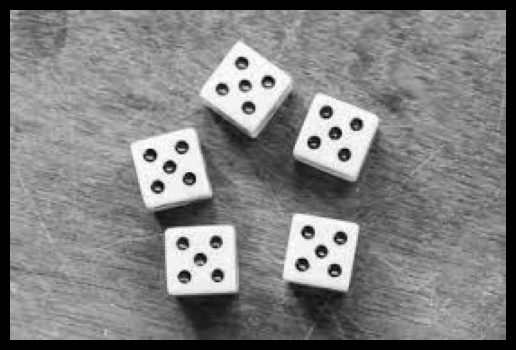

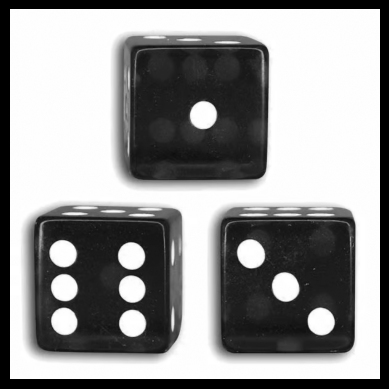

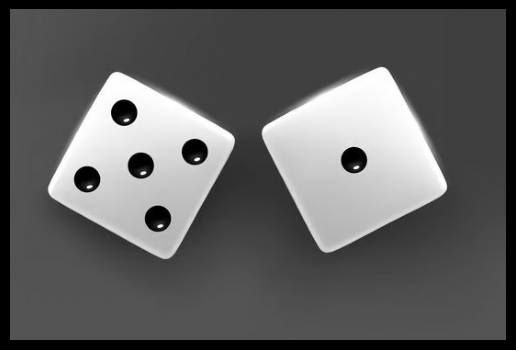

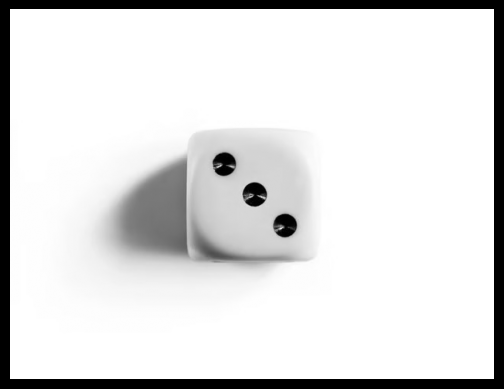

In [275]:
show_in_matplotlib(image_1)
show_in_matplotlib(image_2)
show_in_matplotlib(image_3)
show_in_matplotlib(image_4)

In [276]:
image_1_inverted = cv2.bitwise_not(image_1)
image_2_inverted = image_2.copy()
image_3_inverted = cv2.bitwise_not(image_3)
image_4_inverted = cv2.bitwise_not(image_4)

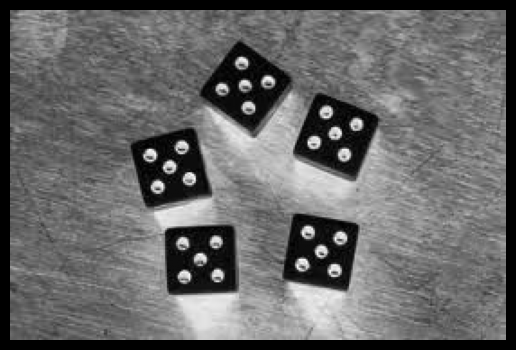

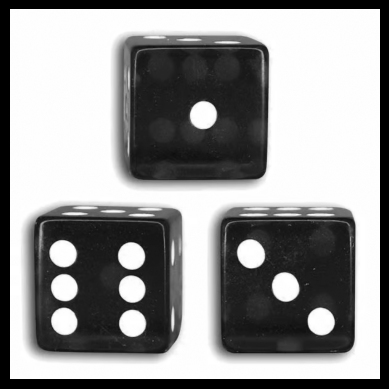

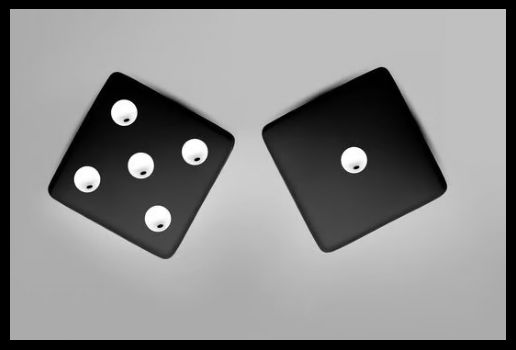

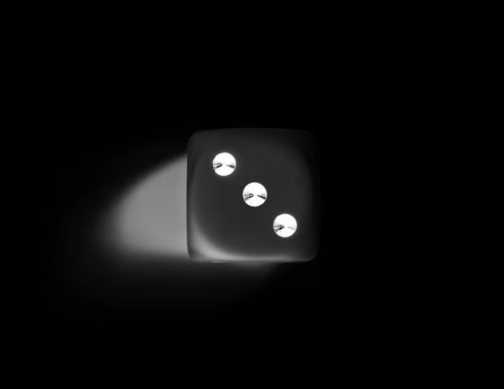

In [277]:
show_in_matplotlib(image_1_inverted)
show_in_matplotlib(image_2_inverted)
show_in_matplotlib(image_3_inverted)
show_in_matplotlib(image_4_inverted)

In [278]:
_ , image_1_threshold = cv2.threshold(image_1_inverted, 90, 255, cv2.THRESH_BINARY)
_ , image_2_threshold = cv2.threshold(image_2_inverted, 127, 255, cv2.THRESH_BINARY)
_ , image_3_threshold = cv2.threshold(image_3_inverted, 90, 255, cv2.THRESH_BINARY)
_ , image_4_threshold = cv2.threshold(image_4_inverted, 90, 255, cv2.THRESH_BINARY)

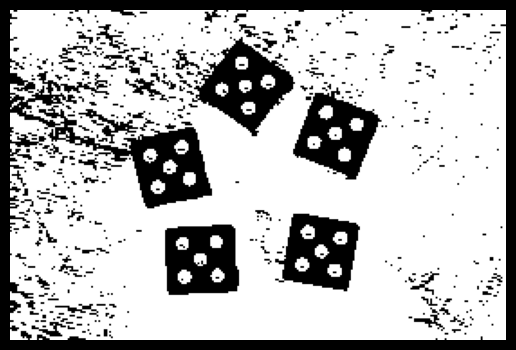

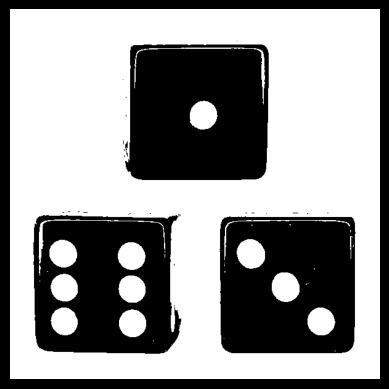

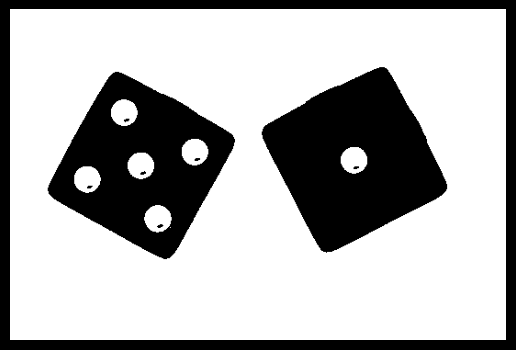

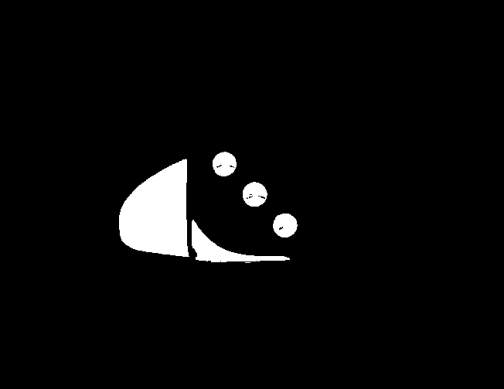

In [279]:
show_in_matplotlib(image_1_threshold)
show_in_matplotlib(image_2_threshold)
show_in_matplotlib(image_3_threshold)
show_in_matplotlib(image_4_threshold)

In [280]:
def draw_rectangle(contour,image,count):
    x,y,w,h = cv2.boundingRect(contour)
    cv2.rectangle(image,(x,y),(x+w,y+h),(0,0,0),3)
    count = count + 1
    return count

In [281]:
contours_image1,hierarchy_image1 = cv2.findContours(image_1_threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours_image2,hierarchy_image2 = cv2.findContours(image_2_threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours_image3,hierarchy_image3 = cv2.findContours(image_3_threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours_image4,hierarchy_image4 = cv2.findContours(image_4_threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
image_1_count = 0
image_2_count = 0
image_3_count = 0
image_4_count = 0
result_image1 = image_1.copy()
result_image2 = image_2.copy()
result_image3 = image_3.copy()
result_image4 = image_4.copy()
for i,contour in enumerate(contours_image1):
    area = cv2.contourArea(contour)
    if hierarchy_image1[0][i][3] not in [-1,0,5] and 25 < area < 1000:
        image_1_count = draw_rectangle(contour, result_image1, image_1_count)
for i,contour in enumerate(contours_image2):
    area = cv2.contourArea(contour)
    if hierarchy_image2[0][i][3] not in [-1,0] and area > 1000:
        image_2_count = draw_rectangle(contour, result_image2, image_2_count)
for i,contour in enumerate(contours_image3):
    area = cv2.contourArea(contour)
    if hierarchy_image3[0][i][3] not in [-1,0] and area > 25:
        image_3_count = draw_rectangle(contour, result_image3, image_3_count)
for i,contour in enumerate(contours_image4):
    area = cv2.contourArea(contour)
    if hierarchy_image4[0][i][3] == -1 and 25 < area < 1000:
        image_4_count = draw_rectangle(contour, result_image4, image_4_count)
# show_in_matplotlib(_result)
# print(count)

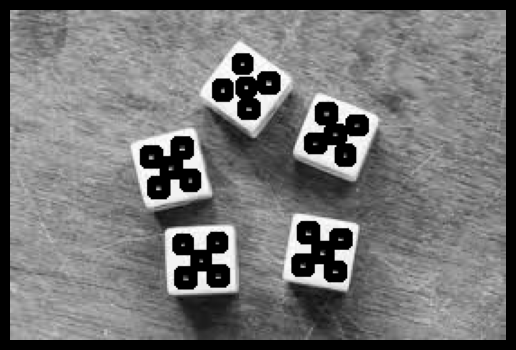

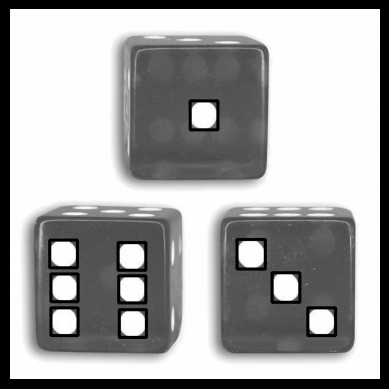

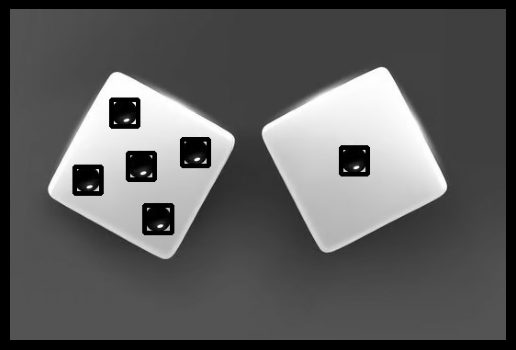

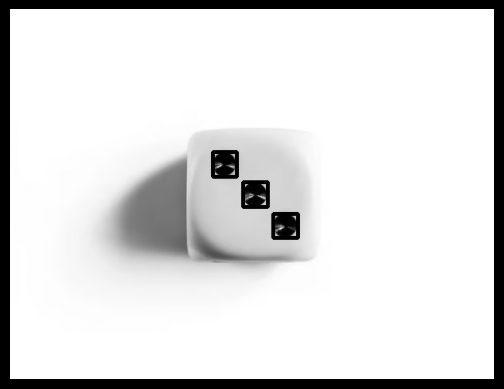

In [282]:
show_in_matplotlib(result_image1)
show_in_matplotlib(result_image2)
show_in_matplotlib(result_image3)
show_in_matplotlib(result_image4)

In [283]:
output_image1 = np.hstack((image_1,result_image1))
output_image2 = np.hstack((image_2,result_image2))
output_image3 = np.hstack((image_3,result_image3))
output_image4 = np.hstack((image_4,result_image4))
cv2.imwrite("output/result1.jpg",output_image1)
cv2.imwrite("output/result2.jpg",output_image2)
cv2.imwrite("output/result3.jpg",output_image3)
cv2.imwrite("output/result4.jpg",output_image4)

True